# Examen
## Aprendizaje Automatico
### Clasificacion por KNN

Daniel Gonzalez - 14/04/2025

## Cargar la Fuente


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
from google.colab import files

In [77]:
df = pd.read_csv('/content/drive/MyDrive/Notebooks/DB/KNN/titanic.csv')

In [78]:
display(df.head())

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Conocer los Datos

In [79]:
for c in df.columns:
    null_count = np.sum(pd.isnull(df[c]))  # Contar valores nulos
    data_types = df[c].dropna().apply(type).unique()  # Obtener tipos de datos únicos sin NaN
    print(f'Column: {c} - Nulls: {null_count} - Data Types: {data_types}')

Column: pclass - Nulls: 0 - Data Types: [<class 'int'>]
Column: survived - Nulls: 0 - Data Types: [<class 'int'>]
Column: name - Nulls: 0 - Data Types: [<class 'str'>]
Column: sex - Nulls: 0 - Data Types: [<class 'str'>]
Column: age - Nulls: 263 - Data Types: [<class 'float'>]
Column: sibsp - Nulls: 0 - Data Types: [<class 'int'>]
Column: parch - Nulls: 0 - Data Types: [<class 'int'>]
Column: ticket - Nulls: 0 - Data Types: [<class 'str'>]
Column: fare - Nulls: 1 - Data Types: [<class 'float'>]
Column: cabin - Nulls: 1014 - Data Types: [<class 'str'>]
Column: embarked - Nulls: 2 - Data Types: [<class 'str'>]
Column: boat - Nulls: 823 - Data Types: [<class 'str'>]
Column: body - Nulls: 1188 - Data Types: [<class 'float'>]
Column: home.dest - Nulls: 564 - Data Types: [<class 'str'>]


In [80]:
df_numeric = df.drop(['name', 'sex','ticket','cabin','embarked','boat','home.dest'], axis=1)

In [81]:
corr_matrix = df_numeric.corr()
corr_matrix['survived'].sort_values(ascending=False)


,survived
survived,1.000000
fare,0.244265
parch,0.082660
sibsp,-0.027825
age,-0.055513
pclass,-0.312469
body,NaN


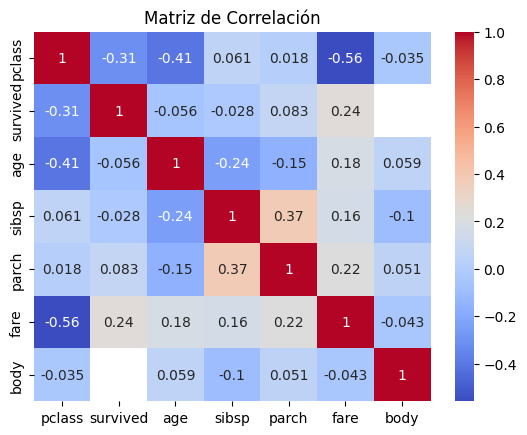

In [82]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [83]:
df = df.drop(['sibsp','parch','name','ticket','body','cabin','boat','home.dest'], axis=1)
df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)
df = df[['pclass', 'age', 'sex', 'embarked','fare','survived']]
display(df.head())

,pclass,age,sex,embarked,fare,survived
0,1,29,female,S,211.3375,1
1,1,0,male,S,151.5500,1
2,1,2,female,S,151.5500,0
3,1,30,male,S,151.5500,0
4,1,25,female,S,151.5500,0


## Analizar los Datos



In [84]:
for c in df.columns:
    null_count = np.sum(pd.isnull(df[c]))  # Contar valores nulos
    data_types = df[c].dropna().apply(type).unique()  # Obtener tipos de datos únicos sin NaN
    print(f'Column: {c} - Nulls: {null_count} - Data Types: {data_types}')

Column: pclass - Nulls: 0 - Data Types: [<class 'int'>]
Column: age - Nulls: 0 - Data Types: [<class 'int'>]
Column: sex - Nulls: 0 - Data Types: [<class 'str'>]
Column: embarked - Nulls: 2 - Data Types: [<class 'str'>]
Column: fare - Nulls: 1 - Data Types: [<class 'float'>]
Column: survived - Nulls: 0 - Data Types: [<class 'int'>]


In [85]:
df.describe()

,pclass,age,fare,survived
count,1309.000000,1309.000000,1308.000000,1309.000000
mean,2.294882,23.858671,33.295479,0.381971
std,0.837836,17.593239,51.758668,0.486055
min,1.000000,0.000000,0.000000,0.000000
25%,2.000000,7.000000,7.895800,0.000000
50%,3.000000,24.000000,14.454200,0.000000
75%,3.000000,35.000000,31.275000,1.000000
max,3.000000,80.000000,512.329200,1.000000


Imputaremos los datos de fare (tarifa) y embarked (Donde subieron) con la mediana y la moda respectivamente.

In [86]:
df['fare'] = df['fare'].fillna(df["fare"].mean())
df['embarked'] = df['embarked'].fillna(df["embarked"].mode()[0])

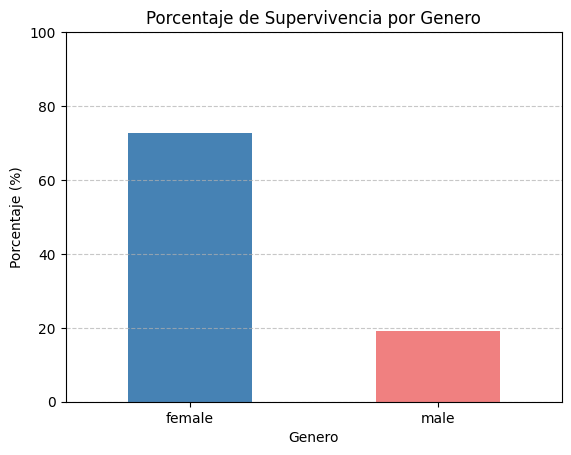

In [87]:
survival_rate = df.groupby('sex')['survived'].mean() * 100
survival_rate.plot(kind='bar', color=['steelblue', 'lightcoral'])
plt.title('Porcentaje de Supervivencia por Genero')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Genero')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

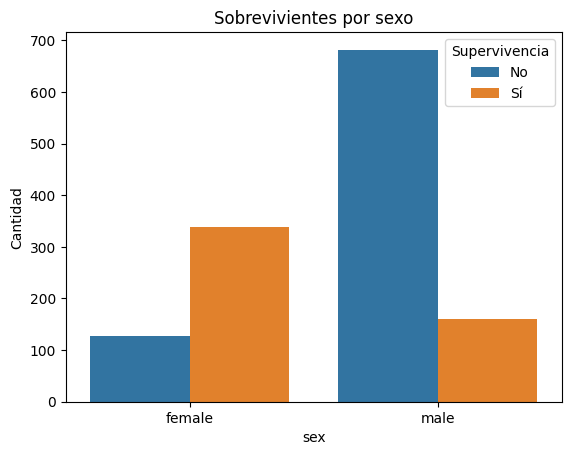

In [88]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title("Sobrevivientes por sexo")
plt.ylabel("Cantidad")
plt.legend(title='Supervivencia', labels=['No', 'Sí'])
plt.show()

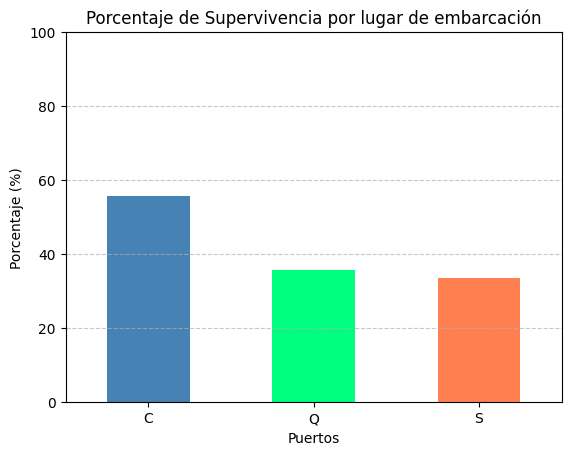

In [89]:
embarked_rate = df.groupby('embarked')['survived'].mean() * 100
embarked_rate.plot(kind='bar', color=['steelblue', 'springgreen', 'coral'])
plt.title('Porcentaje de Supervivencia por lugar de embarcación')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Puertos')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

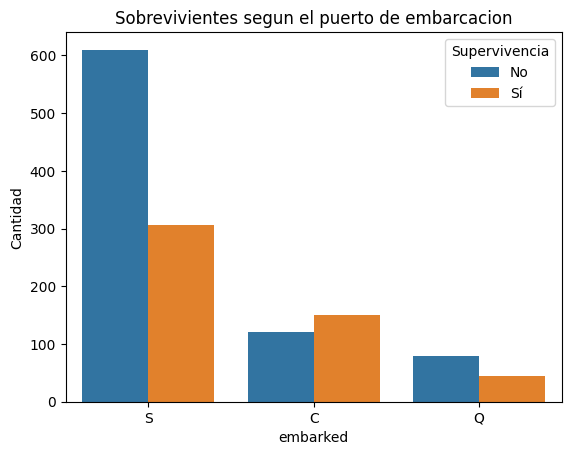

In [90]:
sns.countplot(data=df, x='embarked', hue='survived')
plt.title("Sobrevivientes segun el puerto de embarcacion")
plt.ylabel("Cantidad")
plt.legend(title='Supervivencia', labels=['No', 'Sí'])
plt.show()

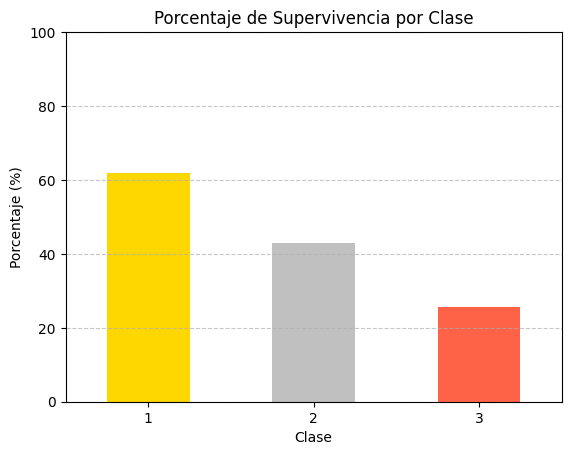

In [91]:
pclass_rate = df.groupby('pclass')['survived'].mean() * 100
pclass_rate.plot(kind='bar', color=['gold', 'silver', 'tomato'])
plt.title('Porcentaje de Supervivencia por Clase')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Clase')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

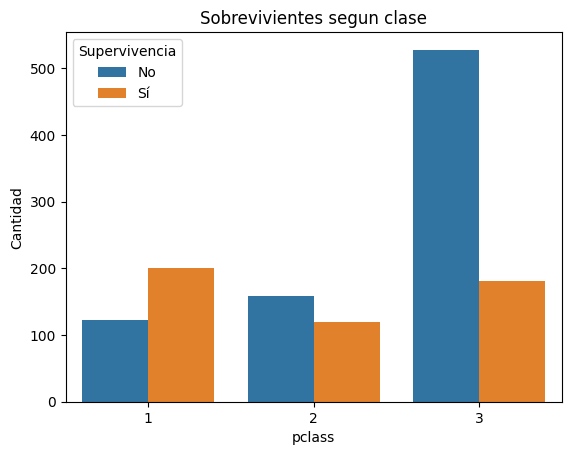

In [92]:
sns.countplot(data=df, x='pclass', hue='survived')
plt.title("Sobrevivientes segun clase")
plt.ylabel("Cantidad")
plt.legend(title='Supervivencia', labels=['No', 'Sí'])
plt.show()

## Preparar los datos

In [93]:
df['embarked'].replace({'S': 1, 'C': 2, 'Q': 3}, inplace=True)
df['sex'].replace({'female': 0, 'male': 1}, inplace=True)

<ipython-input-93-fcd8407f6dee>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].replace({'S': 1, 'C': 2, 'Q': 3}, inplace=True)
<ipython-input-93-fcd8407f6dee>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['embarked'].replace({'S': 1, 'C': 2, 'Q': 3}, inplace=True)
<ipython-inp

In [94]:
def scale_zero_one(df):
    df2 = df.copy()
    for col in df2.select_dtypes(include=['int64', 'float64']).columns:
        minCol = df2[col].min()
        maxCol = df2[col].max()
        df2[col] = (df2[col] - minCol) / (maxCol - minCol)
    return df2
df2=scale_zero_one(df)

In [95]:
df2

,pclass,age,sex,embarked,fare,survived
0,0.0,0.3625,0.0,0.0,0.412503,1.0
1,0.0,0.0000,1.0,0.0,0.295806,1.0
2,0.0,0.0250,0.0,0.0,0.295806,0.0
3,0.0,0.3750,1.0,0.0,0.295806,0.0
4,0.0,0.3125,0.0,0.0,0.295806,0.0
...,...,...,...,...,...,...
1304,1.0,0.1750,0.0,0.5,0.028213,0.0
1305,1.0,0.0000,0.0,0.5,0.028213,0.0
1306,1.0,0.3250,1.0,0.5,0.014102,0.0
1307,1.0,0.3375,1.0,0.5,0.014102,0.0


In [96]:
features = df2.drop('survived', axis=1)
target = df2['survived']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target, random_state=42)

In [98]:
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values
y_test_np = y_test.values

In [99]:
# Distancia euclidiana
def e_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

In [100]:
def knn_predict(X_train, y_train, X_test_point, k):
    distances = []
    for i, x_train_point in enumerate(X_train):
        dist = e_distance(X_test_point, x_train_point)
        distances.append((dist, y_train[i]))

    # Ordenar por distancia y tomar los k más cercanos
    neighbors = sorted(distances, key=lambda x: x[0])[:k]
    classes = [label for _, label in neighbors]

    # Votación por mayoría
    return Counter(classes).most_common(1)[0][0]

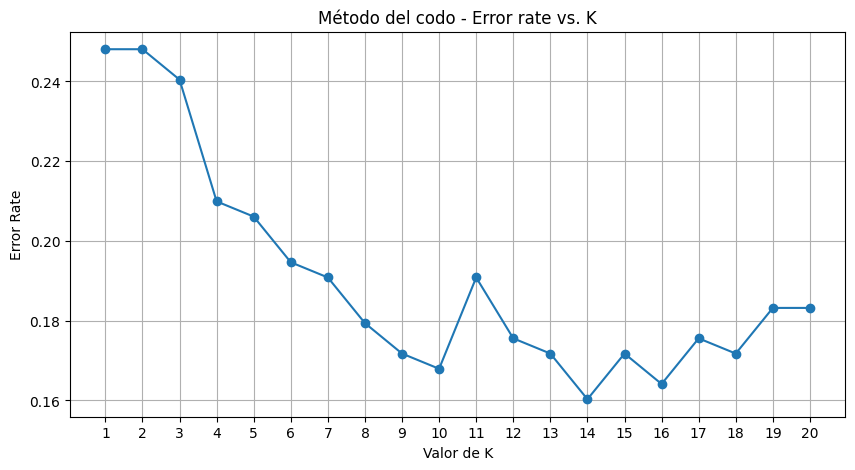

In [101]:
error_rates = []
k_values = range(1, 21)

for k in k_values:
    predictions_k = [knn_predict(X_train_np, y_train_np, x, k) for x in X_test_np]
    error = np.mean(predictions_k != y_test_np)
    error_rates.append(error)

# 7. Graficar método del codo
plt.figure(figsize=(10, 5))
plt.plot(k_values, error_rates, marker='o')
plt.title('Método del codo - Error rate vs. K')
plt.xlabel('Valor de K')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [109]:
k = 14

predictions = []
for x_test_point in X_test_np:
    pred = knn_predict(X_train_np, y_train_np, x_test_point, k)
    predictions.append(pred)

## Test

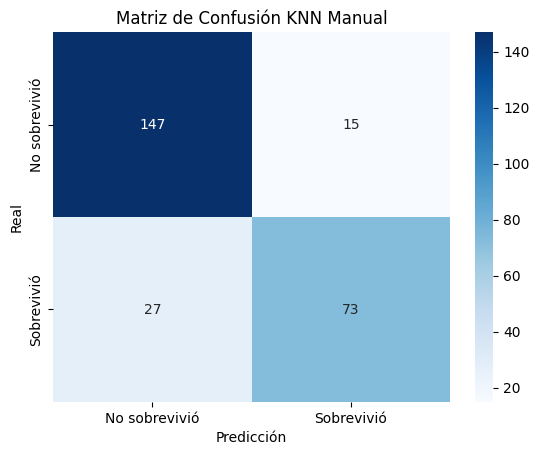

In [110]:
# Matriz de confusión
cm = confusion_matrix(y_test_np, predictions)

# Mostrar la matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No sobrevivió", "Sobrevivió"], yticklabels=["No sobrevivió", "Sobrevivió"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión KNN Manual")
plt.show()

In [111]:
df_test = df.loc[X_test.index].copy()
df_test['predicted'] = predictions
df_test['res'] = df_test['survived'] == df_test['predicted']

In [105]:
display(df_test)

,pclass,age,sex,embarked,fare,survived,predicted,res
1028,3,0,0,3,24.1500,1,1.0,True
1121,3,0,1,2,22.3583,1,0.0,False
1155,3,0,1,1,7.7750,0,0.0,True
1251,3,30,1,1,8.0500,0,0.0,True
721,3,36,1,1,7.4958,0,0.0,True
...,...,...,...,...,...,...,...,...
952,3,22,1,1,7.7750,0,0.0,True
969,3,30,0,1,15.5500,0,0.0,True
125,1,0,1,1,0.0000,0,0.0,True
836,3,20,1,1,9.8458,0,0.0,True


## Metricas

In [112]:
hit = df_test['res'].value_counts()[True]
miss = df_test['res'].value_counts()[False]
print(f'Valores correctos: {hit} \nValores fallados: {miss}')

Valores correctos: 220 
Valores fallados: 42


In [113]:
y_true = df_test['survived'].tolist()
y_pred = df_test['predicted'].tolist()

TP = TN = FP = FN = 0

# Comparacion de resultados
for real, pred in zip(y_true, y_pred):
    if real == 1 and pred == 1:
        TP += 1
    elif real == 0 and pred == 0:
        TN += 1
    elif real == 0 and pred == 1:
        FP += 1
    elif real == 1 and pred == 0:
        FN += 1

# Calcular métricas
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
accuracy_percent = accuracy * 100

# Mostrar resultados
print(f"True Positives: {TP}")
print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")



True Positives: 73
True Negatives: 147
False Positives: 15
False Negatives: 27


In [114]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Error Rate: {error_rate:.3f}")
print(f"accuracy_percent:{accuracy_percent:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Accuracy: 0.840
Error Rate: 0.160
accuracy_percent:83.969
Precision: 0.830
Recall: 0.730
